# 05 - Vizualizacija naucenih karakteristika
U ovom notebook-u analiziramo nacine na koji trenirani model donosi odluke. Za interpretaciju finalnog fine-tuned VGG-16 modela koristi se Grad-CAM (Gradient-weighted Class Activation Mapping). Grad-CAM omogucava vizuelizaciju delova ulazne slike koji su najvise uticali na predikciju modela. Analiza se vrsi nad finalnim VGG-16 modelom dobijenim nakon fine-tuning faze.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import drive
from tensorflow.keras.applications.vgg16 import preprocess_input
print("TensorFlow verzija:", tf.__version__)

TensorFlow verzija: 2.20.0


In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Provera GPU-a
gpu_devices = tf.config.list_physical_devices("GPU")

if gpu_devices:
    print("GPU je dostupan.")
    print("GPU uredjaji:", gpu_devices)
else:
    print("GPU nije dostupan.")

GPU je dostupan.
GPU uredjaji: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Ucitavanje finalnog fine-tuned modela
MODEL_DIR = "/content/drive/MyDrive/MU-projekat/models"
FINETUNED_MODEL_PATH = os.path.join(MODEL_DIR, "vgg16_finetuned.keras")

if not os.path.exists(FINETUNED_MODEL_PATH):
  raise FileNotFoundError(f"Fine-tuned model nije pronadjen: {FINETUNED_MODEL_PATH}")

model = tf.keras.models.load_model(FINETUNED_MODEL_PATH)

print("Fine-tuned model je uspesno ucitan.")

Fine-tuned model je uspesno ucitan.


In [ ]:
model.summary()

Model: "vgg16_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        257 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 29,268,293 (111.65 MB)

 Trainable params: 7,211,009 (27.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,422,020 (55.02 MB)

In [ ]:
# Izdvajanje VGG-16 konvolucione baze
base_model = model.get_layer("vgg16")

print("Naziv baze:", base_model.name)
print("Broj slojeva u VGG-16:", len(base_model.layers))

Naziv baze: vgg16
Broj slojeva u VGG-16: 19


In [ ]:
# Prikaz poslednjih slojeva baze
for layer in base_model.layers[-8:]:
  print(
      f"{layer.name:20s} "
      f"{str(layer.output.shape):20s} "
      f"trainable={layer.trainable}"
  )

block4_conv1         (None, 28, 28, 512)  trainable=False
block4_conv2         (None, 28, 28, 512)  trainable=False
block4_conv3         (None, 28, 28, 512)  trainable=False
block4_pool          (None, 14, 14, 512)  trainable=False
block5_conv1         (None, 14, 14, 512)  trainable=True
block5_conv2         (None, 14, 14, 512)  trainable=True
block5_conv3         (None, 14, 14, 512)  trainable=True
block5_pool          (None, 7, 7, 512)    trainable=True


In [ ]:
# Grad-CAM funkcija

# poslednji konvolucioni sloj VGG-16 baze
LAST_CONV_LAYER_NAME = "block5_conv3"

# model koji vraca:
# 1. izlaz poslednjeg konvolucionog sloja
# 2. izlaz cele VGG-16 baze
vgg_grad_model = tf.keras.Model(inputs=base_model.input, outputs=[base_model.get_layer(LAST_CONV_LAYER_NAME).output, base_model.output])

# slojevi klasifikacione glave iz glavnog modela
gap_layer = model.get_layer("global_average_pooling2d")
dense_layer = model.get_layer("dense")
dropout_layer = model.get_layer("dropout")
output_layer = model.get_layer("dense_1")

In [ ]:
def make_gradcam_heatmap(img_array):
    """
    Generise Grad-CAM mapu za jednu sliku.
    Parametar: img_array - slika oblika (1, 224, 224, 3) sa vrednostima piksela u opsegu 0-255
    Povratne vrednosti:
        heatmap - Grad-CAM mapa normalizovana na interval [0, 1]
        dog_probability - verovatnoca klase dog
        predicted_class - predvidjena klasa
    """

    # VGG-16 preprocessing
    processed_img = preprocess_input(tf.cast(img_array, tf.float32))

    with tf.GradientTape() as tape:

        # izlaz poslednjeg konvolucionog sloja
        # i izlaz cele VGG-16 baze
        conv_outputs, vgg_outputs = vgg_grad_model(processed_img, training=False)

        # prolazak kroz klasifikacionu glavu
        x = gap_layer(vgg_outputs)
        x = dense_layer(x)
        x = dropout_layer(x, training=False)

        # poslednji Dense sloj ima sigmoid aktivaciju.
        # ovde rucno racunamo vrednost PRE sigmoid funkcije.
        kernel, bias = output_layer.weights

        logit = tf.matmul(x, kernel) + bias

        # verovatnoca klase dog
        dog_probability = tf.sigmoid(logit)

        # za Grad-CAM koristimo logit da izbegnemo
        # problem zasicenja sigmoid funkcije.
        if float(dog_probability[0][0]) >= 0.5:
            predicted_class = "dog"
            class_score = logit[:, 0]
        else:
            predicted_class = "cat"
            class_score = -logit[:, 0]

    # gradijenti klase u odnosu na feature mape
    grads = tape.gradient(class_score, conv_outputs)

    # prosecan znacaj svakog kanala
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Uklanjanje batch dimenzije
    conv_outputs = conv_outputs[0]

    # Tezinska kombinacija feature mapa
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    # Grad-CAM zadrzava pozitivne doprinose
    heatmap = tf.maximum(heatmap, 0)

    # Normalizacija na interval [0, 1]
    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    return (heatmap.numpy(), float(dog_probability[0][0]), predicted_class)

In [ ]:
# Ucitavanje test skupa
PROJECT_DIR = "/content/Household-Animals-Classification"
SPLIT_PATH = os.path.join(PROJECT_DIR, "split.csv")

DATASET_DIR = ("/content/drive/MyDrive/MU-projekat/data/dogs-vs-cats/train/train")

if not os.path.exists(SPLIT_PATH):
    raise FileNotFoundError(f"split.csv nije pronadjen: {SPLIT_PATH}")

if not os.path.exists(DATASET_DIR):
  raise FileNotFoundError(f"Dataset nije pronadjen: {DATASET_DIR}")

split_df = pd.read_csv(SPLIT_PATH)

test_df = split_df[split_df["split"] == "test"].copy()

test_df["filepath"] = test_df["filename"].apply(lambda filename: os.path.join(DATASET_DIR, filename))

print("Broj slika u test skupu:", len(test_df))
test_df.head()

Broj slika u test skupu: 1000


,filename,label,split,filepath
24000,cat.9153.jpg,cat,test,/content/drive/MyDrive/MU-projekat/data/dogs-v...
24001,cat.11372.jpg,cat,test,/content/drive/MyDrive/MU-projekat/data/dogs-v...
24002,cat.7977.jpg,cat,test,/content/drive/MyDrive/MU-projekat/data/dogs-v...
24003,dog.6279.jpg,dog,test,/content/drive/MyDrive/MU-projekat/data/dogs-v...
24004,cat.7904.jpg,cat,test,/content/drive/MyDrive/MU-projekat/data/dogs-v...


In [ ]:
# Izbor primera iz test skupa
cat_example = test_df[test_df["label"] == "cat"].iloc[0]

dog_example = test_df[test_df["label"] == "dog"].iloc[0]

print("Primer macke:", cat_example["filename"])
print("Primer psa:", dog_example["filename"])

Primer macke: cat.9153.jpg
Primer psa: dog.6279.jpg


In [ ]:
# Ucitavanje jedne slike
IMG_SIZE = 224

def load_single_image(filepath):
    """
    Ucitava jednu sliku i priprema je za model.
    Vraća:
        original_image - originalna slika za prikaz
        img_array - slika dimenzije (1, 224, 224, 3)
    """

    image = tf.keras.utils.load_img(filepath)

    original_image = np.array(image)

    resized_image = tf.keras.utils.load_img(filepath, target_size=(IMG_SIZE, IMG_SIZE))

    img_array = tf.keras.utils.img_to_array(resized_image)

    img_array = np.expand_dims(img_array, axis=0)

    return original_image, img_array

In [ ]:
# Ucitavanje jednog primera macke
cat_original, cat_array = load_single_image(cat_example["filepath"])

print("Stvarna klasa:", cat_example["label"])
print("Dimenzija originalne slike:", cat_original.shape)
print("Dimenzija ulaza za model:", cat_array.shape)

Stvarna klasa: cat
Dimenzija originalne slike: (374, 500, 3)
Dimenzija ulaza za model: (1, 224, 224, 3)


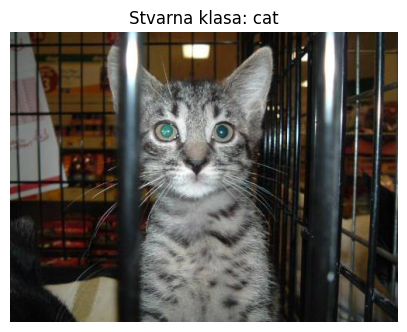

In [ ]:
# Prikaz slike
plt.figure(figsize=(5, 5))

plt.imshow(cat_original)
plt.axis("off")
plt.title(f"Stvarna klasa: {cat_example['label']}")

plt.show()

In [ ]:
# poziv Grad-CAM
cat_heatmap, cat_dog_probability, cat_prediction = (make_gradcam_heatmap(cat_array))

print("Stvarna klasa:", cat_example["label"])
print("Predvidjena klasa:", cat_prediction)
print(f"Verovatnoca klase dog: "
    f"{cat_dog_probability:.6f}")
print("Dimenzija Grad-CAM mape:", cat_heatmap.shape)

Stvarna klasa: cat
Predvidjena klasa: cat
Verovatnoca klase dog: 0.000000
Dimenzija Grad-CAM mape: (14, 14)


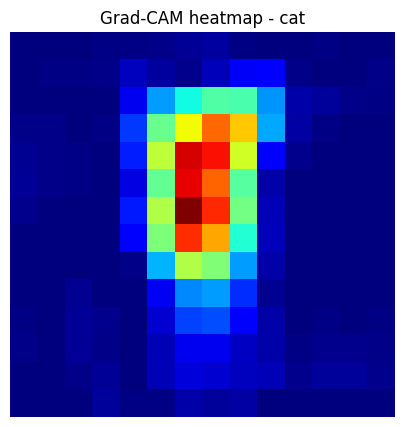

In [ ]:
# Prikaz Grad-CAM heatmape
plt.figure(figsize=(5, 5))

plt.imshow(cat_heatmap, cmap="jet")

plt.axis("off")
plt.title("Grad-CAM heatmap - cat")

plt.show()

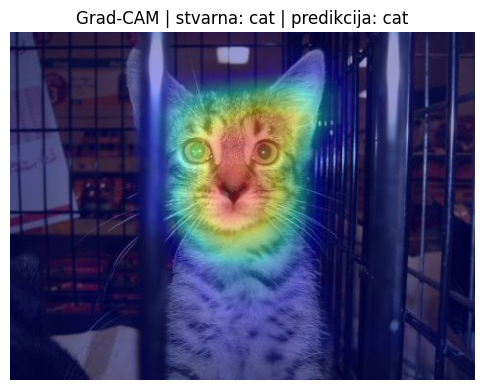

In [ ]:
# Preklapanje Grad-CAM mape preko originalne slike

# heatmap se povecava sa 14x14 na dimenzije originalne slike
heatmap_resized = tf.image.resize(cat_heatmap[..., np.newaxis], (cat_original.shape[0], cat_original.shape[1])).numpy().squeeze()

plt.figure(figsize=(6, 6))

# originalna slika
plt.imshow(cat_original)

# Grad-CAM mapa preko slike
plt.imshow(heatmap_resized, cmap="jet", alpha=0.4)

plt.axis("off")
plt.title(f"Grad-CAM | stvarna: cat | predikcija: {cat_prediction}")

plt.show()


Ovde Grad-CAM pokazuje da su za predikciju klase cat najvaznije bile karakteristke lica i glave, sto dokazuje da je model naucio semanticki relevantne vizuelne karakteristike.
U narednom delu isto cemo uraditi i za klasu dog.

In [ ]:
# Grad-CAM za primer psa
dog_original, dog_array = load_single_image(dog_example["filepath"])

dog_heatmap, dog_dog_probability, dog_prediction = (make_gradcam_heatmap(dog_array))

print("Stvarna klasa:", dog_example["label"])
print("Predvidjena klasa:", dog_prediction)
print(f"Verovatnoca klase dog: "
    f"{dog_dog_probability:.6f}")
print("Dimenzija Grad-CAM mape:", dog_heatmap.shape)

Stvarna klasa: dog
Predvidjena klasa: dog
Verovatnoca klase dog: 1.000000
Dimenzija Grad-CAM mape: (14, 14)


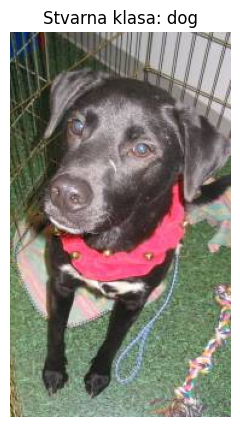

In [ ]:
# Prikaz slike
plt.figure(figsize=(5, 5))

plt.imshow(dog_original)
plt.axis("off")
plt.title(f"Stvarna klasa: {dog_example['label']}")

plt.show()

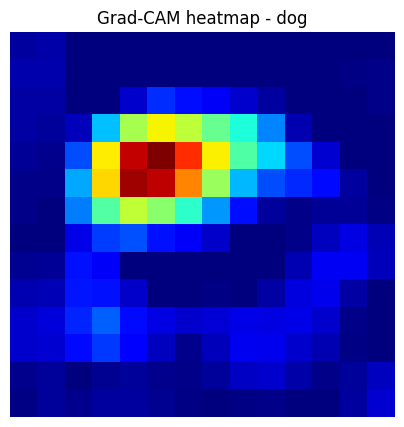

In [ ]:
# Prikaz Grad-CAM heatmape
plt.figure(figsize=(5, 5))

plt.imshow(dog_heatmap, cmap="jet")

plt.axis("off")
plt.title("Grad-CAM heatmap - dog")

plt.show()

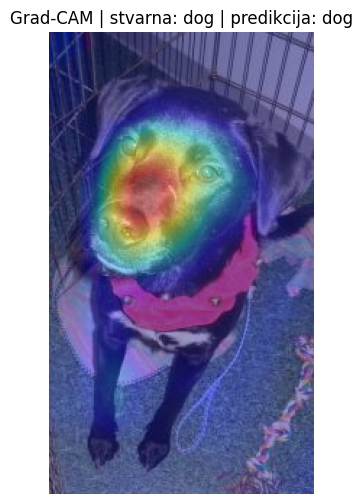

In [ ]:
# Preklapanje Grad-CAM mape preko originalne slike

# heatmap se povećava na dimenzije originalne slike
dog_heatmap_resized = tf.image.resize(dog_heatmap[..., np.newaxis],(dog_original.shape[0], dog_original.shape[1])).numpy().squeeze()

plt.figure(figsize=(6, 6))

plt.imshow(dog_original)

plt.imshow(dog_heatmap_resized, cmap="jet", alpha=0.4)

plt.axis("off")

plt.title(f"Grad-CAM | stvarna: dog | predikcija: {dog_prediction}")

plt.show()

Za oba primera Grad-CAM daje smisleni rezultat. Kod psa fokus je bio na njusci i centralnom delu glave.

In [ ]:
# Dodatni primeri
additional_cats = (test_df[test_df["label"] == "cat"].iloc[1:3])

additional_dogs = (test_df[test_df["label"] == "dog"].iloc[1:3])

gradcam_examples = pd.concat([additional_cats, additional_dogs], ignore_index=True)

gradcam_examples[["filename", "label"]]

,filename,label
0,cat.11372.jpg,cat
1,cat.7977.jpg,cat
2,dog.6206.jpg,dog
3,dog.1249.jpg,dog


In [ ]:
# Funkcija za prikaz Grad-CAM rezultata
def show_gradcam_example(example):
    """
    Prikazuje originalnu sliku i Grad-CAM vizualizaciju za jedan primer iz test skupa.
    """

    original_image, img_array = load_single_image(example["filepath"])

    heatmap, dog_probability, predicted_class = (make_gradcam_heatmap(img_array))

    # povecavanje Grad-CAM mape na dimenzije originalne slike
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (original_image.shape[0], original_image.shape[1])).numpy().squeeze()

    # prikaz originalne slike
    plt.figure(figsize=(5, 5))
    plt.imshow(original_image)
    plt.axis("off")
    plt.title(f"Stvarna klasa: {example['label']}")
    plt.show()

    # prikaz Grad-CAM mape preko originalne slike
    plt.figure(figsize=(5, 5))

    plt.imshow(original_image)

    plt.imshow(heatmap_resized, cmap="jet", alpha=0.4)

    plt.axis("off")

    plt.title(f"Grad-CAM | stvarna: {example['label']} | "
              f"predikcija: {predicted_class}")

    plt.show()

    print("Fajl:", example["filename"])
    print("Stvarna klasa:", example["label"])
    print("Predvidjena klasa:", predicted_class)
    print(f"Verovatnoca klase dog: "
          f"{dog_probability:.6f}")
    print("-" * 60)

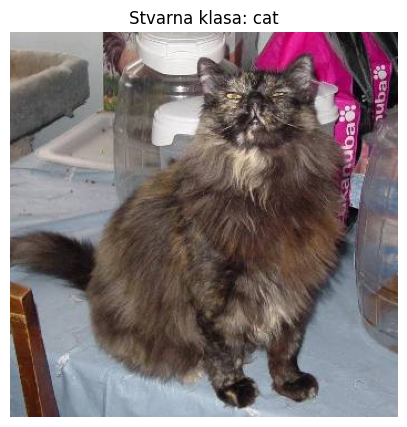

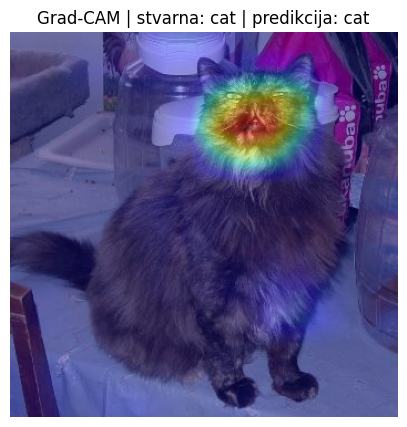

Fajl: cat.11372.jpg
Stvarna klasa: cat
Predvidjena klasa: cat
Verovatnoca klase dog: 0.000043
------------------------------------------------------------


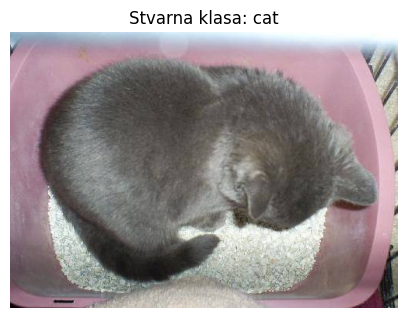

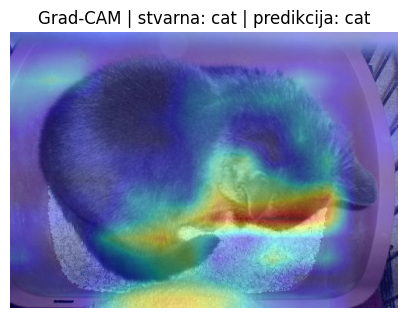

Fajl: cat.7977.jpg
Stvarna klasa: cat
Predvidjena klasa: cat
Verovatnoca klase dog: 0.002188
------------------------------------------------------------


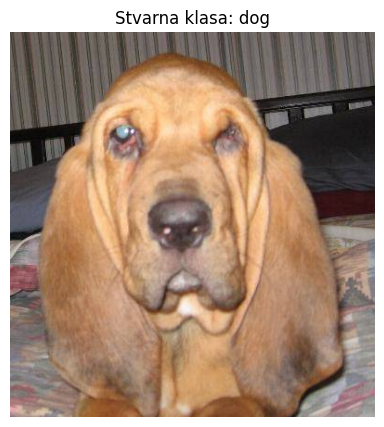

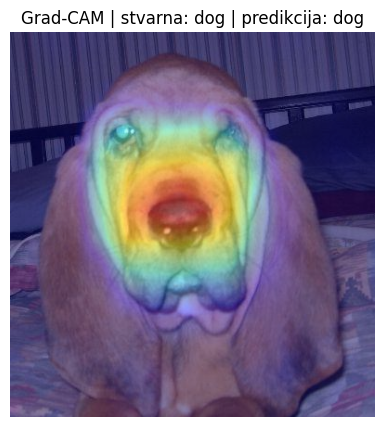

Fajl: dog.6206.jpg
Stvarna klasa: dog
Predvidjena klasa: dog
Verovatnoca klase dog: 1.000000
------------------------------------------------------------


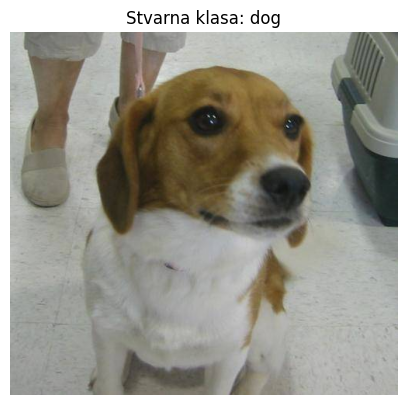

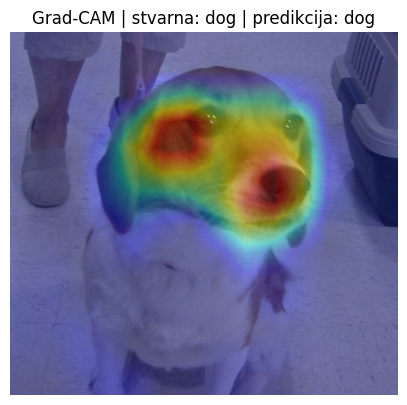

Fajl: dog.1249.jpg
Stvarna klasa: dog
Predvidjena klasa: dog
Verovatnoca klase dog: 1.000000
------------------------------------------------------------


In [ ]:
# Grad-CAM za vise primera iz test skupa
for _, example in gradcam_examples.iterrows():
    show_gradcam_example(example)

## Analiza Grad-CAM vizualizacija
Grad-CAM vizualizacija pokazuje da se fine-tuned VGG-16 model pri klasifikaciji pasa i macaka uglavnom fokusira na semanticki relevantne delove zivotinja. Kod primera macke najveca aktivacija se uglavnom pojavljuje u oblasti glave, ociju i njuske. Kod pasa su najizrazenije oblasti oko njuske, ociju i centralnog dela lica. Ovakav obrazac ukazuje da model nije zasnovao svoje odluke prvenstveno na karakteristikama pozadine, vec na vizuelnim osobinama samih zivotinja koje su relevantne za razlikovanje dve klase. Grad-CAM mape se razlikuju od slike do slike i ne moraju precizno obuhvatiti celu zivotinju, jer prikazuju oblasti koje su najvise doprinele konkretnoj predikciji modela.

## Napomena o Grad-CAM implementaciji
Posto je izlaz modela definisan sigmoid funkcijom za binarnu klasifikaciju, Grad-CAM je racunat na logit vrednoscu pre sigmoid aktivacije. Time se izbegava problem zasicenja sigmoid funkcije kod veoma sigurnih predikcija, kada gradijenti mogu postati veoma mali ili jednaki nuli.

## Performanse finalnog modela

Grad-CAM analiza se vrsi nad finalnim fine-tuned VGG-16 modelom. Na istom test skupu model je u prethodnoj fazi ostvario sledece rezultate:

- Accuracy: 99.00%
- Precision: 99.00%
- Recall: 99.00%
- F1-score: 99.00%

Matrica konfuzije finalnog modela bila je:

\[
\begin{bmatrix}
495 & 5 \\
5 & 495
\end{bmatrix}
\]

Ovi rezultati pokazuju da Grad-CAM interpretaciju vrsimo nad modelom koji postize veoma visoku i uravnotezenu tacnost za obe klase.